In [1]:
#Importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Please take 1–3 screenshots of the charts you created, and include 1–2 sentences 
interpreting each chart. Email them to me before our next session.

In [2]:
#Obtaining cleaned dataset from last session
from pathlib import Path

DATA_DIR = Path("/Users/kevin/Downloads/streaming-bi-template/streaming-bi-template/Data")

def load_csv(filename: str) -> pd.DataFrame:
    fp = DATA_DIR / filename
    if fp.exists():
        print(f"Loaded: {fp}")
        return pd.read_csv(fp)
    raise FileNotFoundError(f"Could not find {filename} in {DATA_DIR}")

df_movie = load_csv("MoviesOnStreamingPlatforms_Cleaned.csv")
df_tv = load_csv("TVShowsOnStreamingPlatforms_Cleaned.csv")

print(df_movie)
print(df_tv)

Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\MoviesOnStreamingPlatforms_Cleaned.csv
Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\TVShowsOnStreamingPlatforms_Cleaned.csv
        ID                                     Title  Year  Age  \
0        1                              The Irishman  2019  18+   
1        2                                    Dangal  2016   7+   
2        3  David Attenborough: A Life on Our Planet  2020   7+   
3        4         Lagaan: Once Upon a Time in India  2001   7+   
4        5                                      Roma  2018  18+   
...    ...                                       ...   ...  ...   
9510  9511                        Most Wanted Sharks  2020  18+   
9511  9512             Doc McStuffins: The Doc Is In  2020  18+   
9512  9513                     Ultimate Viking Sword  2019  18+   
9513  9514           Hunt for the Abominable Snowman  2011  18+   
9514  9515       Women o

# 1. Grouped bar chart

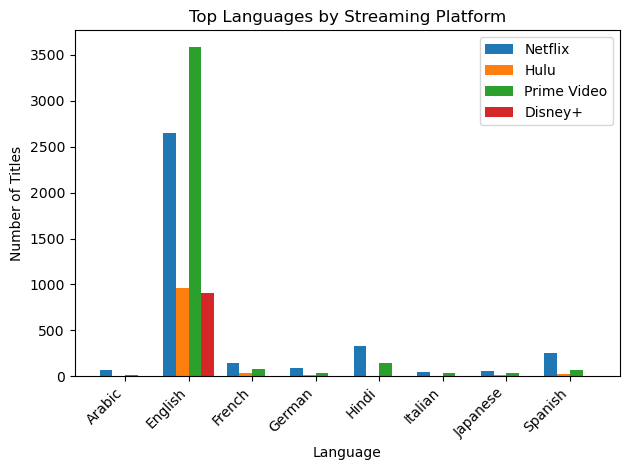

In [3]:
df = df_movie.copy()

#Split and explode Languages
df["Language"] = df["Language"].str.split(",")
df = df.explode('Language')
df["Language"] = df["Language"].str.strip()

#Selecting the top languages
top_languages = df["Language"].value_counts().head(8).index

#Count titles platform per language
platforms = ["Netflix", "Hulu", "Prime Video", "Disney+"]

counts = (
    df[df["Language"].isin(top_languages)].groupby('Language')[platforms].sum()
)

x = np.arange(len(counts.index))
width = 0.2

plt.figure()

for i, platform in enumerate(platforms):
    plt.bar(
        x + i * width,
        counts[platform],
        width,
        label=platform
    )

plt.xlabel('Language')
plt.ylabel('Number of Titles')
plt.title('Top Languages by Streaming Platform')
plt.xticks(x + width * 1.5, counts.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

We used a grouped bar chart to see which languages are the most common on streaming Platforms. We noticed that English is highest on all four platforms and Hindi is the second highest common language on Netflix.

# 2. Line Chart

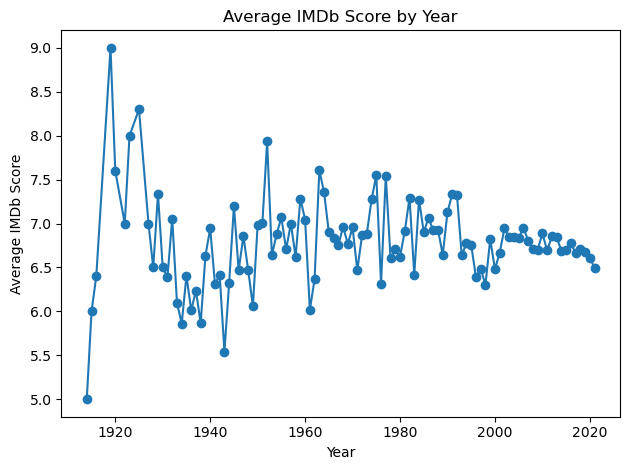

In [4]:
yearly_score_avg = (
    df_movie.groupby("Year")["IMDb"].mean().sort_index()
)

plt.figure()
plt.plot(yearly_score_avg.index, yearly_score_avg.values, marker = "o")
plt.xlabel("Year")
plt.ylabel("Average IMDb Score")
plt.title("Average IMDb Score by Year")
plt.tight_layout()
plt.show()

This line graph shows the average IMDb ratings score per year. We see that the highest IMDb rating on average is around 1920.

# 3. Heatmap

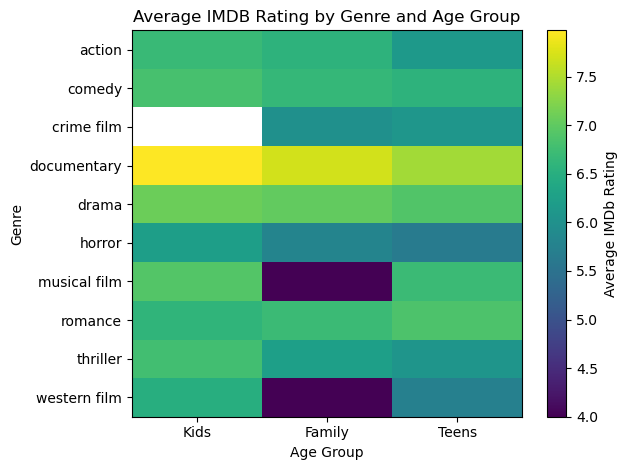

In [5]:
df["Genre"] = df["Genre"].str.lower().str.strip()

# Handle romance FIRST (captures "romance film", "romantic comedy")
df.loc[df["Genre"].str.contains("romance"), "Genre"] = "romance"

df.loc[df["Genre"].str.contains("action"), "Genre"] = "action"
df.loc[df["Genre"].str.contains("comedy"), "Genre"] = "comedy"
df.loc[df["Genre"].str.contains("drama"), "Genre"] = "drama"
df.loc[df["Genre"].str.contains("documentary"), "Genre"] = "documentary"
df.loc[df["Genre"].str.contains("horror"), "Genre"] = "horror"
df.loc[df["Genre"].str.contains("thriller"), "Genre"] = "thriller"

df["Age_Group"] = pd.cut(
    df["Age_Min"],
    bins = [0, 7, 13, 18, 100],
    labels = ["Kids", "Family", "Teens", "Adults"],
    right=True,
    include_lowest = True
)

top_genres = df["Genre"].value_counts().head(10).index

heatmap_data = (
    df[df["Genre"].isin(top_genres)]
        .groupby(["Genre", "Age_Group"], observed=True)["IMDb"]
        .mean()
        .unstack()
)

#Plot the figure
plt.figure()

plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average IMDb Rating")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Age Group")
plt.ylabel("Genre")
plt.title("Average IMDB Rating by Genre and Age Group")
plt.tight_layout()
plt.show()

The heatmap shows the average IMDb ratings across different genre and age-group combinations, with darker colors representing higher ratings. It reveals that documentary and drama films tend to receive higher ratings across age groups, while horror films generally score lower, especially for younger audiences.